In [ ]:
import sys
from pathlib import Path

# Add src/ to Python path for local module imports
sys.path.insert(0, str(Path.cwd().parent / "src"))

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import os
from openai import OpenAI
from openai.types.fine_tuning import SupervisedMethod, SupervisedHyperparameters


from dotenv import load_dotenv  
from pprint import pprint

import constants

from prompting_utils import create_system_prompt
from model_utils import from_series_to_basemodel

import json

import model_utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from pathlib import Path
import wandb
from wandb.integration.openai import autolog

# Preliminari

In [2]:
# Configurazione OpenAI
load_dotenv()
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

# Configurazione WandB
#wandb.login(key=os.getenv("WANDB_API_KEY"))

# Parametri
base_dir = Path.cwd().parent
TEMPERATURE = 0.0
ANN_MODEL = constants.RectalCancerStagingData
SYSTEM_PROMPT_FILE_NAME = constants.SYSTEM_PROMPT_6

MODEL = constants.OPENAI_GPT_4_1_NANO

UPLOAD_DATA = True
OVERSAMPLING = True

#Carica system prompt da file
system_prompt_path = base_dir / "data" / "prompts" / SYSTEM_PROMPT_FILE_NAME
system_prompt = create_system_prompt(system_prompt_path, ANN_MODEL)

In [3]:
print(MODEL)

gpt-4.1-nano-2025-04-14


In [4]:
if True:
    print(system_prompt)

<ruolo>
Sei un assistente medico radiologico esperto nella stadiazione del carcinoma rettale tramite RM.
Il tuo compito è estrarre informazioni strutturate dal referto RM fornito e restituire esclusivamente un oggetto JSON valido conforme allo schema seguente.
</ruolo>

<schema>
{
  "morfologia": "solido_polipoide | solido_anulare | mucinoso",
  "ore_inizio": "int | null",
  "ore_fine": "int | null",
  "spessore_parietale": "int | null",
  "estensione_cranio_caudale": "int | null",
  "distanza_oai": "int | null",
  "posizione": {
    "basso": "no | si",
    "medio": "no | si",
    "alto": "no | si",
    "giunzione": "no | si"
  },
  "riflessione_peritoneale_anteriore": "sotto | cavallo | non_descritto",
  "infiltrazione_tessuto_adiposo": "no | si_5mm | si_5mm_plus",
  "infiltrazione_sfinteri": "no | si",
  "infiltrazione_organi_extra": "no | si",
  "infiltrazione_organi_dettagli": {
    "muscolo_elevatore": "no | si",
    "pavimento_pelvico": "no | si",
    "altro": "no | si"
  },
  "c

# Load Data

In [5]:
# Carichiamo i nostri file csv
file_names = {
    'train': constants.TRAIN_SPLIT_FILE_NAME,
    'validation': constants.VALIDATION_SPLIT_FILE_NAME
}

paths = {split: Path('../data/' + file_name) for split, file_name in file_names.items()}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data = data['train'], data['validation']

################################
# Convert float columns to Int64
################################
float_cols = train_data.select_dtypes("float").columns
for col in float_cols:
    train_data[col] = train_data[col].round().astype("Int64")
    validation_data[col] = validation_data[col].round().astype("Int64")
    
# Check duplicatest
assert set(train_data.id) & set(validation_data.id) == set(), "There are overlapping IDs between test and validation sets!"

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 187
len(validation_data) = 63


# Oversampling

In [6]:
def hamming_distance_matrix(df, categorical_cols):
    """Matrice di distanza Hamming normalizzata."""
    df_cat = df[categorical_cols].values
    n = len(df_cat)
    k = len(categorical_cols)
    dist = np.zeros((n, n))

    for i in range(n):
        dist[i, :] = np.sum(df_cat[i] != df_cat, axis=1) / k

    return dist

def lof_rarity(df, categorical_cols, n_neighbors=20):
    dist = hamming_distance_matrix(df, categorical_cols)

    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        metric="precomputed",
        contamination="auto"
    )
    lof.fit(dist)

    result = df.copy()
    # Più negativo = più outlier
    result["lof_score"] = -lof.negative_outlier_factor_
    return result


In [7]:
train_data.head()

,id,report_text,profile,morfologia,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,posizione,...,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_linfonodi,depositi_tumorali,emvi,stadio_T,stadio_N,mrf,metastasi,split
0,52,IN CORRISPONDENZA DELLA PARETE POSTERO LATERAL...,GuidoImbemba,solido_polipoide,5,10,<NA>,<NA>,0,['basso'],...,conosciuto,1,['altro'],si,si,T4b,N+,no,MX,train
1,55,RM ADDOME INFERIORE\nESAME ESEGUITO MEDIANTE S...,PietroPaoloAzzaro,solido_polipoide,3,12,18,50,60,['medio'],...,non_conosciuto,0,"['rettali_superiori', 'mesorettali', 'iliaci']",no,no,T3ab,N+,no,M1,train
2,59,IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA...,GuidoImbemba,solido_anulare,6,12,<NA>,20,70,['medio'],...,conosciuto,1,['otturatori'],no,no,T1-2,N+,no,MX,train
3,64,A PREVALENTE SVILUPPO NEL RETTO ALTO CON ESTEN...,GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,90,70,"['alto', 'medio']",...,non_conosciuto,0,"['rettali_superiori', 'mesorettali']",no,no,T3ab,N+,si,MX,train
4,72,"AL PASSAGGIO RETTO-SIGMA, A CIRCA 10 CM DAL MA...",GuidoImbemba,solido_anulare,12,12,14,60,100,['giunzione'],...,conosciuto,0,[],si,no,T3cd,N+,no,MX,train


,id,report_text,profile,morfologia,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,posizione,...,linfonodi_sospetti,sedi_linfonodi,depositi_tumorali,emvi,stadio_T,stadio_N,mrf,metastasi,split,lof_score
0,52,IN CORRISPONDENZA DELLA PARETE POSTERO LATERAL...,GuidoImbemba,solido_polipoide,5,10,<NA>,<NA>,0,['basso'],...,1,['altro'],si,si,T4b,N+,no,MX,train,1.407179
1,55,RM ADDOME INFERIORE\nESAME ESEGUITO MEDIANTE S...,PietroPaoloAzzaro,solido_polipoide,3,12,18,50,60,['medio'],...,0,"['rettali_superiori', 'mesorettali', 'iliaci']",no,no,T3ab,N+,no,M1,train,1.192970
2,59,IN CORRISPONDENZA DELLA PARETE LATERALE DESTRA...,GuidoImbemba,solido_anulare,6,12,<NA>,20,70,['medio'],...,1,['otturatori'],no,no,T1-2,N+,no,MX,train,1.162299
3,64,A PREVALENTE SVILUPPO NEL RETTO ALTO CON ESTEN...,GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,90,70,"['alto', 'medio']",...,0,"['rettali_superiori', 'mesorettali']",no,no,T3ab,N+,si,MX,train,1.255700
4,72,"AL PASSAGGIO RETTO-SIGMA, A CIRCA 10 CM DAL MA...",GuidoImbemba,solido_anulare,12,12,14,60,100,['giunzione'],...,0,[],si,no,T3cd,N+,no,MX,train,1.183363


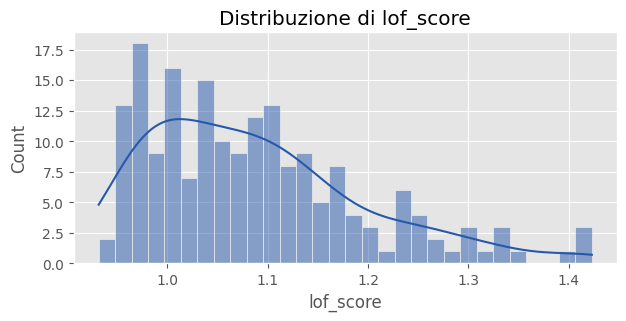

q85 = np.float64(1.1978222761330155)
len(chunk_1) = 159
len(chunk_2) = 28


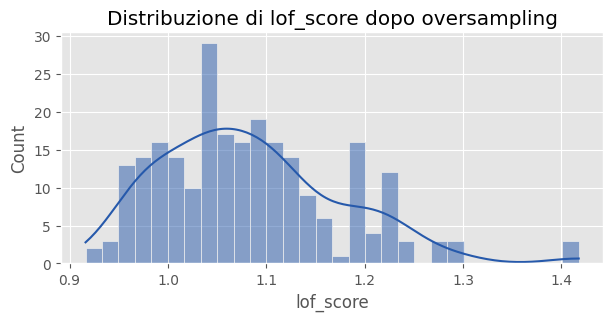

In [8]:
if OVERSAMPLING:
    numeric_cols = model_utils.get_regression_fields(ANN_MODEL)
    categorical_cols = [f for f in ANN_MODEL.model_fields if f not in numeric_cols]

    #train_data, _ = rarity_with_numeric(train_data, categorical_cols, numeric_cols)
    train_data = lof_rarity(train_data, categorical_cols, n_neighbors=20)
    
    display(train_data.head())
    
    plt.figure(figsize=(7, 3))
    sns.histplot(train_data["lof_score"], kde=True, color="#2659ab", bins=30)
    plt.xlabel("lof_score")
    plt.title("Distribuzione di lof_score")
    plt.show()
    
    q85 = train_data.lof_score.quantile(0.85)
    print(f'{q85 = }')
    
    chunk_1 = train_data[(train_data.lof_score < q85)]
    chunk_2 = train_data[(train_data.lof_score >= q85)]
    
    print(f'{len(chunk_1) = }')
    print(f'{len(chunk_2) = }')
    
    data_train_oversampled = pd.concat([chunk_1] + 3*[chunk_2], ignore_index=True)
    data_train_oversampled = data_train_oversampled.sample(frac=1, random_state=constants.SEED).reset_index(drop=True)
    
    df_plot = lof_rarity(data_train_oversampled, categorical_cols, n_neighbors=20)
    
    plt.figure(figsize=(7, 3))
    sns.histplot(df_plot["lof_score"], kde=True, color="#2659ab", bins=30)
    plt.xlabel("lof_score")
    plt.title("Distribuzione di lof_score dopo oversampling")
    plt.show()
    
    data_train_oversampled.drop(columns=["lof_score"], inplace=True)

# Upload data to Openai dashboard

## Create local fine-tuning datasets

Il dataset jsonl dovrà contenere righe con il formato chat completetion. Ogni riga dovrà essere:

```
{
  "messages": [
    { "role": "system", "content": <system_prompt>}
    { "role": "user", "content": <report_text> },
    { "role": "assistant", "content": <correct_annotation> },
  ]
}
```

In [10]:
def prepare_example_conversation(row):
    return {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": row['report_text']},
            {"role": "assistant", "content": from_series_to_basemodel(row, ANN_MODEL).model_dump_json()},
        ]
    }
    
def write_jsonl(data_list: list, filename: str) -> None:
    with open(filename, "w") as out:
        for ddict in data_list:
            jout = json.dumps(ddict) + "\n"
            out.write(jout)
            
def upload_file(file_name: str, purpose: str) -> str:
    with open(file_name, "rb") as file_fd:
        response = client.files.create(file=file_fd, purpose=purpose)
    return response.id

In [11]:
if UPLOAD_DATA:
    validation_list = validation_data.apply(prepare_example_conversation, axis=1).tolist()
    
    if OVERSAMPLING:
        print("Uploading oversampling...")
        train_list = data_train_oversampled.apply(prepare_example_conversation, axis=1).tolist()
        training_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_TRAIN_OVERSAMPLING_FILE_NAME
        write_jsonl(train_list, training_file_path)
    else:
        print("Uploading without oversampling...")
        train_list = train_data.apply(prepare_example_conversation, axis=1).tolist()
        training_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_TRAIN_FILE_NAME
        write_jsonl(train_list, training_file_path)

    validation_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_VALIDATION_FILE_NAME
    write_jsonl(validation_list, validation_file_path)
    
    training_file_id = upload_file(training_file_path, "fine-tune")
    validation_file_id = upload_file(validation_file_path, "fine-tune")

    print("Training file ID:", training_file_id)
    print("Validation file ID:", validation_file_id)

Uploading oversampling...
Training file ID: file-5oGYqedq9ACHRFGKYqXu6d
Validation file ID: file-FnPBT7guqBNaKsvqjAJFZU


# Fine tuning

In [12]:
print(MODEL)

gpt-4.1-nano-2025-04-14


In [13]:
validation_file_id

'file-FnPBT7guqBNaKsvqjAJFZU'

In [14]:
fine_tuning_job = client.fine_tuning.jobs.create(
  training_file=training_file_id,
  validation_file=validation_file_id,
  model=MODEL,
  seed=constants.SEED,
  suffix="report-extractor-oversampling" if OVERSAMPLING else "report-extractor",
  method={
    "type": "supervised",
    "supervised": SupervisedMethod(
      hyperparameters=SupervisedHyperparameters(
        n_epochs=3)
    )
  },
  integrations=[
    {
      "type": "wandb",
      "wandb": {"project": "PRIN"}
    }
  ]
)

job_id = fine_tuning_job.id

In [15]:
print(job_id)

ftjob-RFKqDfaVywyu2gS5lq3fpETJ


In [16]:
print("Job ID:", fine_tuning_job.id)
print("Status:", fine_tuning_job.status)

Job ID: ftjob-RFKqDfaVywyu2gS5lq3fpETJ
Status: validating_files


In [17]:
response = client.fine_tuning.jobs.retrieve(job_id)

print("Job ID:", response.id)
print("Status:", response.status)
print("Trained Tokens:", response.trained_tokens)

Job ID: ftjob-RFKqDfaVywyu2gS5lq3fpETJ
Status: validating_files
Trained Tokens: None


In [19]:
job_id = 'ftjob-RFKqDfaVywyu2gS5lq3fpETJ'
response = client.fine_tuning.jobs.list_events(job_id)

events = response.data
events.reverse()

for event in events:
    print(event.message)

Created fine-tuning job: ftjob-RFKqDfaVywyu2gS5lq3fpETJ
Validating training file: file-5oGYqedq9ACHRFGKYqXu6d and validation file: file-FnPBT7guqBNaKsvqjAJFZU


In [14]:
response = client.fine_tuning.jobs.retrieve(job_id)
fine_tuned_model_id = response.fine_tuned_model

if fine_tuned_model_id is None:
    raise RuntimeError(
        "Fine-tuned model ID not found. Your job has likely not been completed yet."
    )

print("Fine-tuned model ID:", fine_tuned_model_id)

Fine-tuned model ID: ft:gpt-4.1-nano-2025-04-14:luca-tramonti:report-extractor:DNDCPvfn
